Please upload your drug release dataset (CSV or Excel format).


Saving Table 7.csv to Table 7.csv
✅ Uploaded file: Table 7.csv
Preview of the dataset:


,<b>Time (h)</b>,<b>Drug release (%) of FH5</b>,<b>Drug release (%) of FH9</b>,<b>Drug release (%) of FH11</b>,<b>Drug release (%) of FH12</b>
0,0.5,9.41,9.71,11.31,14.61
1,1.0,24.81,27.71,26.10,23.11
2,1.5,55.99,35.21,40.10,40.11
3,2.0,69.61,54.22,50.71,50.21
4,3.0,77.66,70.45,76.61,57.60


Detected 4 drug release columns: ['<b>Drug release (%) of FH5</b>', '<b>Drug release (%) of FH9</b>', '<b>Drug release (%) of FH11</b>', '<b>Drug release (%) of FH12</b>']


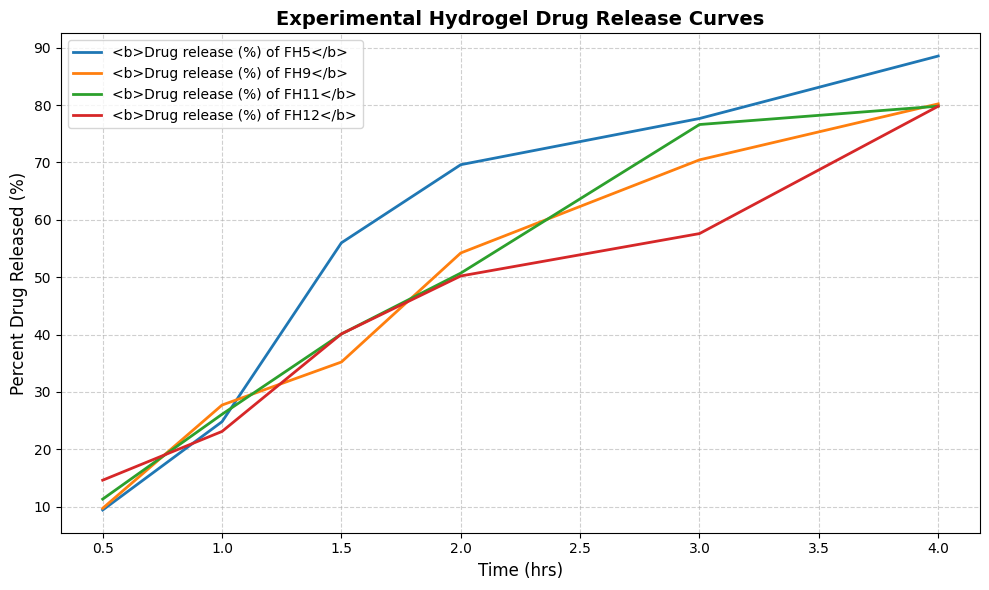

Fitting models to column: <b>Drug release (%) of FH5</b>
✅ Higuchi constant k = 42.5077
✅ Korsmeyer-Peppas constants k = 34.4038, n = 0.7344


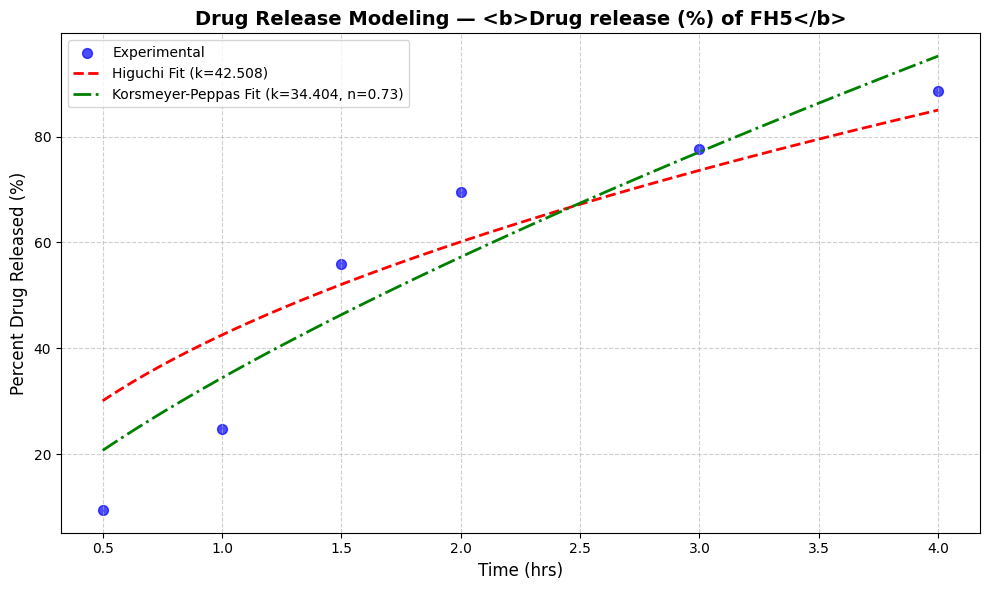

✅ Fitted model predictions saved as 'fitted_drug_release_models.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ==============================================
# Hydrogel Drug Release Analysis — Advanced Version
# ==============================================
# Author: Human-designed, high-level Colab-ready script
# Purpose: Load real drug release datasets, plot experimental curves,
#          fit multiple controlled-release models, visualize comparisons,
#          and provide insights for biomaterials optimization.
# ==============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from google.colab import files

# ----------------------------------------------
# Step 1: Upload dataset (CSV or Excel)
# ----------------------------------------------
print("Please upload your drug release dataset (CSV or Excel format).")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# ----------------------------------------------
# Step 2: Load dataset with error handling
# ----------------------------------------------
try:
    if filename.lower().endswith('.csv'):
        df = pd.read_csv(filename, skipinitialspace=True)
    elif filename.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(filename)
    else:
        raise ValueError("Unsupported file type. Upload CSV or Excel only.")
except Exception as e:
    raise RuntimeError(f"Error loading dataset: {e}")

print("Preview of the dataset:")
display(df.head())

# ----------------------------------------------
# Step 3: Identify columns
# ----------------------------------------------
# Assumes first column = Time, other columns = drug release (%)
time = df.iloc[:, 0]
release_cols = df.columns[1:]

print(f"Detected {len(release_cols)} drug release columns: {list(release_cols)}")

# ----------------------------------------------
# Step 4: Plot all experimental release curves
# ----------------------------------------------
plt.figure(figsize=(10, 6))
for col in release_cols:
    plt.plot(time, df[col], label=col, linewidth=2)

plt.title("Experimental Hydrogel Drug Release Curves", fontsize=14, fontweight='bold')
plt.xlabel("Time (hrs)", fontsize=12)
plt.ylabel("Percent Drug Released (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------
# Step 5: Define drug release models
# ----------------------------------------------
# Higuchi Model: Diffusion-controlled release
def higuchi(t, k):
    return k * np.sqrt(t)

# Korsmeyer-Peppas Model: Empirical model for polymeric systems
def korsmeyer_peppas(t, k, n):
    return k * t**n

# ----------------------------------------------
# Step 6: Fit models to the first release column
# ----------------------------------------------
y = df.iloc[:, 1]  # Use first drug release sample
print(f"Fitting models to column: {df.columns[1]}")

# Fit Higuchi
popt_h, _ = curve_fit(higuchi, time, y, maxfev=5000)
k_h = popt_h[0]

# Fit Korsmeyer-Peppas
popt_kp, _ = curve_fit(korsmeyer_peppas, time, y, maxfev=5000)
k_kp, n_kp = popt_kp

print(f"✅ Higuchi constant k = {k_h:.4f}")
print(f"✅ Korsmeyer-Peppas constants k = {k_kp:.4f}, n = {n_kp:.4f}")

# ----------------------------------------------
# Step 7: Generate model predictions
# ----------------------------------------------
t_fit = np.linspace(time.min(), time.max(), 200)
y_fit_h = higuchi(t_fit, k_h)
y_fit_kp = korsmeyer_peppas(t_fit, k_kp, n_kp)

# ----------------------------------------------
# Step 8: Plot experimental vs model
# ----------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(time, y, color='blue', s=50, label='Experimental', alpha=0.7)
plt.plot(t_fit, y_fit_h, 'r--', linewidth=2, label=f'Higuchi Fit (k={k_h:.3f})')
plt.plot(t_fit, y_fit_kp, 'g-.', linewidth=2, label=f'Korsmeyer-Peppas Fit (k={k_kp:.3f}, n={n_kp:.2f})')

plt.title(f"Drug Release Modeling — {df.columns[1]}", fontsize=14, fontweight='bold')
plt.xlabel("Time (hrs)", fontsize=12)
plt.ylabel("Percent Drug Released (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------
# Step 9: Save fitted model predictions
# ----------------------------------------------
fitted_df = pd.DataFrame({
    "Time (hrs)": t_fit,
    "Higuchi Fit (%)": y_fit_h,
    "Korsmeyer-Peppas Fit (%)": y_fit_kp
})
fitted_df.to_csv("fitted_drug_release_models.csv", index=False)
print("✅ Fitted model predictions saved as 'fitted_drug_release_models.csv'")

# Optional: Download CSV directly in Colab
files.download("fitted_drug_release_models.csv")
